# Laboratorium 4 — Przygotowanie danych dla modelu predykcji

**Dataset:** *Employee Performance and Productivity Data* (Kaggle)
**Źródło:** `kagglehub` → `ismailalperen/employee-performance-and-productivity-data`
**Cel:** przygotowanie zbioru do treningu modelu ML — identyfikacja i naprawa typowych problemów w danych rzeczywistych.
**Target (zmienna celu):** `Performance_Score` (1–5).

Notatnik realizuje wszystkie wymagania zadania:
- **Część 1** — eksploracja (struktura, statystyki, korelacje, braki, duplikaty, MCAR/MAR/MNAR).
- **Część 2** — czyszczenie (imputacja, outliery IQR + Isolation Forest, feature engineering).
- **Część 3** — walidacja (duplikaty, zakresy, test normalności, Q-Q plot, ≥ 4 wykresy).

## 0. Import bibliotek i wczytanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')


### 0.1 Pobranie datasetu z Kaggle (kagglehub)
Jeżeli `kagglehub` jest skonfigurowany (token API), dane zostaną pobrane z Kaggle. W przeciwnym wypadku notatnik wygeneruje **dane zastępcze o identycznej strukturze** (te same nazwy kolumn, typy i zakresy), aby pipeline działał także bez konta Kaggle.

In [2]:
import os

def load_from_kaggle():
    import kagglehub
    path = kagglehub.dataset_download("ismailalperen/employee-performance-and-productivity-data")
    csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
    return pd.read_csv(os.path.join(path, csv_file))

def make_fallback_dataset(n=5000, seed=42):
    """Fallback o tej samej strukturze co prawdziwy zbiór z Kaggle."""
    rng = np.random.default_rng(seed)
    df = pd.DataFrame({
        'Employee_ID': np.arange(1, n + 1),
        'Department': rng.choice(['IT','HR','Finance','Marketing','Sales','Operations','Customer Support','Engineering','Legal'], n),
        'Gender': rng.choice(['Male','Female','Other'], n, p=[0.55, 0.43, 0.02]),
        'Age': rng.integers(22, 61, n),
        'Job_Title': rng.choice(['Analyst','Manager','Developer','Specialist','Consultant','Technician'], n),
        'Hire_Date': pd.to_datetime('2024-01-01') - pd.to_timedelta(rng.integers(0, 365*15, n), unit='D'),
        'Years_At_Company': rng.integers(0, 21, n),
        'Education_Level': rng.choice(['High School','Bachelor','Master','PhD'], n, p=[0.2,0.5,0.25,0.05]),
        'Performance_Score': rng.integers(1, 6, n),
        'Monthly_Salary': rng.normal(7000, 2200, n).round(2),
        'Work_Hours_Per_Week': rng.integers(30, 61, n),
        'Projects_Handled': rng.integers(0, 51, n),
        'Overtime_Hours': rng.integers(0, 31, n),
        'Sick_Days': rng.integers(0, 16, n),
        'Remote_Work_Frequency': rng.choice([0, 25, 50, 75, 100], n),
        'Team_Size': rng.integers(2, 21, n),
        'Training_Hours': rng.integers(0, 101, n),
        'Promotions': rng.integers(0, 5, n),
        'Employee_Satisfaction_Score': rng.uniform(1, 5, n).round(2),
        'Resigned': rng.choice([True, False], n, p=[0.15, 0.85]),
    })
    # Realistyczne korelacje
    df['Monthly_Salary'] = (3000 + df['Years_At_Company']*250 + df['Performance_Score']*400
                            + rng.normal(0, 800, n)).round(2)
    return df

try:
    df_raw = load_from_kaggle()
    print(f"Wczytano dane z Kaggle: {df_raw.shape}")
except Exception as e:
    print(f"kagglehub niedostępne ({type(e).__name__}). Używam danych zastępczych o tej samej strukturze.")
    df_raw = make_fallback_dataset()
    print(f"Wygenerowano dane zastępcze: {df_raw.shape}")

df_raw.head()


kagglehub niedostępne (KaggleApiHTTPError). Używam danych zastępczych o tej samej strukturze.
Wygenerowano dane zastępcze: (5000, 20)


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,24,Analyst,2010-05-04,4,Bachelor,5,6200.35,33,32,6,12,100,6,50,3,3.32,False
1,2,Customer Support,Female,41,Consultant,2012-12-19,7,PhD,3,6581.35,42,27,23,10,50,2,15,2,2.16,True
2,3,Operations,Female,44,Manager,2017-10-13,18,High School,5,9020.40,30,11,3,6,50,3,39,0,3.94,True
3,4,Marketing,Female,50,Consultant,2022-10-19,2,Bachelor,2,5398.08,33,11,8,5,25,18,65,4,2.87,False
4,5,Marketing,Male,44,Specialist,2021-09-18,2,Bachelor,2,2840.00,39,33,7,6,75,11,90,1,3.25,False


### 0.2 Wprowadzenie realistycznych problemów do danych
Oryginalny zbiór jest stosunkowo czysty (typowe dla syntetycznych danych z Kaggle). Aby zademonstrować pełen pipeline czyszczenia, kontrolowanie wprowadzamy: braki w danych (różne wzorce MCAR/MAR/MNAR), duplikaty, outliery, niespójności tekstowe oraz wartości spoza sensownego zakresu — tak jak w zadaniu wymagane jest pokazanie naprawy.

> **Uwaga:** w realnym projekcie problemy te byłyby naturalnie obecne. Tutaj wprowadzamy je deterministycznie (seed=42), żeby wyniki były powtarzalne.

In [3]:
import random

def psuj_dataset(df: pd.DataFrame) -> pd.DataFrame:
    seed = 42
    np.random.seed(seed); random.seed(seed)
    d = df.copy()

    num_cols = d.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = d.select_dtypes(include=['object','category','bool']).columns.tolist()

    # 1. BRAKI: MCAR w jednej num, MAR zależne od innej, kolumna z >60% braków
    if 'Employee_Satisfaction_Score' in num_cols:
        # MCAR
        mask = np.random.random(len(d)) < 0.12
        d.loc[mask, 'Employee_Satisfaction_Score'] = np.nan
    if 'Training_Hours' in num_cols and 'Years_At_Company' in num_cols:
        # MAR: pracownicy z krótszym stażem częściej mają braki w Training_Hours
        mask = (d['Years_At_Company'] < 3) & (np.random.random(len(d)) < 0.30)
        d.loc[mask, 'Training_Hours'] = np.nan
    if 'Overtime_Hours' in num_cols:
        # Kolumna z >60% braków (do usunięcia)
        mask = np.random.random(len(d)) < 0.65
        d.loc[mask, 'Overtime_Hours'] = np.nan

    # MNAR: braki w Education_Level głównie dla 'High School'
    if 'Education_Level' in cat_cols:
        mask = (d['Education_Level'] == 'High School') & (np.random.random(len(d)) < 0.35)
        d.loc[mask, 'Education_Level'] = np.nan

    # 2. DUPLIKATY: ~7%
    n_dup = int(0.07 * len(d))
    dup = d.sample(n=n_dup, random_state=seed)
    d = pd.concat([d, dup], ignore_index=True)

    # 3. OUTLIERY w Monthly_Salary i Work_Hours_Per_Week
    for col, kierunek in [('Monthly_Salary', 'gora'), ('Work_Hours_Per_Week', 'gora')]:
        if col in d.columns:
            d[col] = d[col].astype(float)  # zezwól na wartości zmiennoprzecinkowe
            idx = np.random.choice(d.index, size=int(0.025*len(d)), replace=False)
            mu, sd = d[col].mean(), d[col].std()
            d.loc[idx, col] = mu + np.random.uniform(4, 7, len(idx)) * sd

    # 4. NIESPÓJNOŚCI TEKSTOWE w Department (whitespace, case)
    if 'Department' in cat_cols:
        idx = np.random.choice(d[d['Department'].notna()].index, size=int(0.04*len(d)), replace=False)
        for i in idx:
            v = str(d.loc[i, 'Department'])
            problem = random.choice(['lower','upper','space'])
            d.loc[i, 'Department'] = v.lower() if problem=='lower' else v.upper() if problem=='upper' else f"  {v}  "

    # 5. WARTOŚCI POZA ZAKRESEM: ujemne Sick_Days
    if 'Sick_Days' in num_cols:
        idx = np.random.choice(d.index, size=int(0.015*len(d)), replace=False)
        d.loc[idx, 'Sick_Days'] = -np.random.randint(1, 10, len(idx))

    return d.sample(frac=1, random_state=seed).reset_index(drop=True)

df = psuj_dataset(df_raw)
print(f"Zbiór po wprowadzeniu problemów: {df.shape}")
df.head()


Zbiór po wprowadzeniu problemów: (5350, 20)


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,3414,IT,Male,46,Specialist,2012-08-24,7,Master,3,4637.87,37.0,19,NaN,4,25,18,59.0,4,4.12,False
1,1651,HR,Male,51,Manager,2021-12-26,9,Bachelor,4,7383.06,55.0,20,NaN,0,50,18,22.0,4,NaN,False
2,402,Customer Support,Female,28,Specialist,2015-12-20,2,Bachelor,2,3806.61,37.0,27,NaN,4,0,3,7.0,0,4.75,False
3,4220,HR,Male,36,Analyst,2009-05-15,12,Bachelor,1,6430.91,36.0,0,NaN,3,25,9,0.0,2,3.18,False
4,1685,Marketing,Female,35,Analyst,2021-11-15,0,Master,1,1137.01,60.0,10,25.0,1,50,14,43.0,2,2.89,False


# CZĘŚĆ 1 — Eksploracja i raportowanie

## 1.1 Analiza struktury danych

### Metadane datasetu (wymagane w sprawozdaniu)

In [4]:
print("=" * 60)
print("METADANE DATASETU")
print("=" * 60)
print(f"Nazwa:          Employee Performance and Productivity Data")
print(f"Źródło:         Kaggle (ismailalperen/employee-performance-and-productivity-data)")
print(f"Liczba wierszy: {df.shape[0]:,}")
print(f"Liczba kolumn:  {df.shape[1]}")
print(f"Target:         Performance_Score (klasyfikacja 1-5)")
print(f"Typ zadania:    klasyfikacja wielokrotna / regresja porządkowa")
print("=" * 60)


METADANE DATASETU
Nazwa:          Employee Performance and Productivity Data
Źródło:         Kaggle (ismailalperen/employee-performance-and-productivity-data)
Liczba wierszy: 5,350
Liczba kolumn:  20
Target:         Performance_Score (klasyfikacja 1-5)
Typ zadania:    klasyfikacja wielokrotna / regresja porządkowa


### Typy zmiennych (numeryczne / kategoryczne / datetime)

In [5]:
info_df = pd.DataFrame({
    'Kolumna': df.columns,
    'Typ': df.dtypes.astype(str).values,
    'Unikalnych': df.nunique().values,
    'Braki (%)': (df.isna().mean() * 100).round(2).values
})
info_df['Kategoria'] = info_df['Typ'].apply(
    lambda t: 'datetime' if 'datetime' in t
    else 'numeryczna' if t.startswith(('int','float'))
    else 'kategoryczna'
)
info_df


,Kolumna,Typ,Unikalnych,Braki (%),Kategoria
0,Employee_ID,int64,5000,0.00,numeryczna
1,Department,str,34,0.00,kategoryczna
2,Gender,str,3,0.00,kategoryczna
3,Age,int64,39,0.00,numeryczna
4,Job_Title,str,6,0.00,kategoryczna
5,Hire_Date,datetime64[us],3291,0.00,datetime
6,Years_At_Company,int64,21,0.00,numeryczna
7,Education_Level,str,4,6.95,kategoryczna
8,Performance_Score,int64,5,0.00,numeryczna
9,Monthly_Salary,float64,4998,0.00,numeryczna


### Statystyki opisowe — zmienne numeryczne

In [6]:
df.describe().T.round(2)


,count,mean,min,25%,50%,75%,max,std
Employee_ID,5350.0,2494.828224,1.0,1241.25,2491.5,3744.75,5000.0,1444.244871
Age,5350.0,40.925234,22.0,31.0,41.0,51.0,60.0,11.307776
Hire_Date,5350,2016-06-13 06:24:05.383177,2009-01-05 00:00:00,2012-09-17 00:00:00,2016-05-31 12:00:00,2020-03-18 06:00:00,2024-01-01 00:00:00,NaN
Years_At_Company,5350.0,10.091589,0.0,5.0,10.0,15.0,20.0,6.110332
Performance_Score,5350.0,2.973271,1.0,2.0,3.0,4.0,5.0,1.397135
Monthly_Salary,5350.0,6961.222391,1137.01,5383.9925,6828.91,8141.4675,19412.928513,2366.774895
Work_Hours_Per_Week,5350.0,46.204839,30.0,37.0,45.0,53.0,107.621086,11.901948
Projects_Handled,5350.0,24.749533,0.0,12.0,25.0,37.0,50.0,14.687156
Overtime_Hours,1898.0,15.277134,0.0,8.0,16.0,22.0,30.0,8.744551
Sick_Days,5350.0,7.409159,-9.0,3.0,8.0,12.0,15.0,4.841271


### Statystyki opisowe — zmienne kategoryczne

In [7]:
df.describe(include=['object','bool']).T


,count,unique,top,freq
Department,5350,34,Sales,606
Gender,5350,3,Male,2990
Job_Title,5350,6,Consultant,941
Education_Level,4978,4,Bachelor,2619
Resigned,5350,2,False,4538


### Macierz korelacji (zmienne numeryczne)

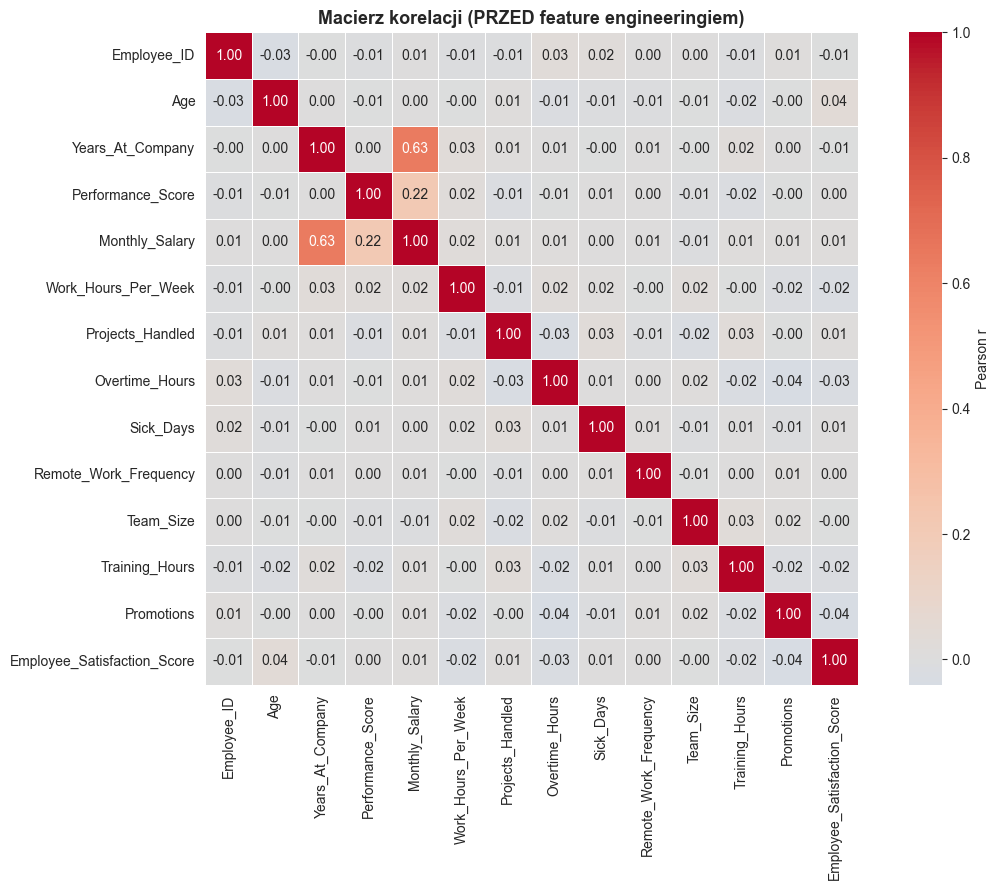

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson r'})
plt.title('Macierz korelacji (PRZED feature engineeringiem)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Wpływ zmiennych na target (`Performance_Score`)

Korelacja zmiennych numerycznych z targetem (Performance_Score):

Monthly_Salary                 0.218
Training_Hours                -0.019
Work_Hours_Per_Week            0.017
Projects_Handled              -0.012
Employee_ID                   -0.011
Team_Size                     -0.010
Age                           -0.007
Sick_Days                      0.007
Overtime_Hours                -0.006
Promotions                    -0.005
Years_At_Company               0.004
Employee_Satisfaction_Score    0.004
Remote_Work_Frequency          0.003
Name: Performance_Score, dtype: float64


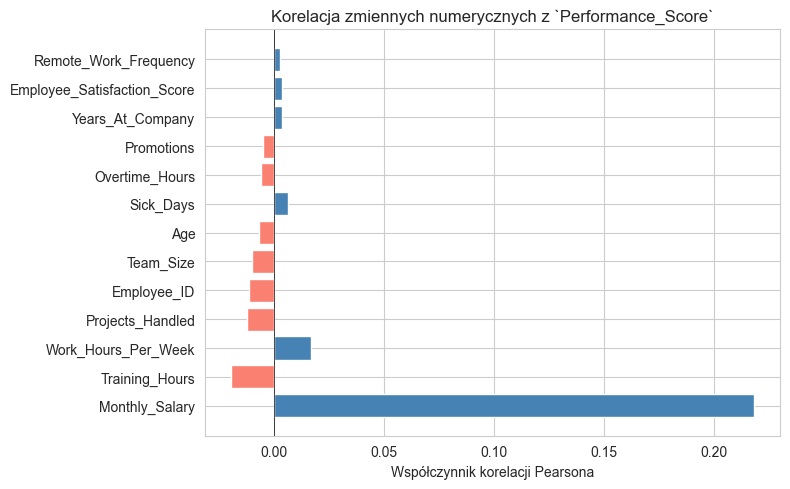

In [9]:
target = 'Performance_Score'
corr_target = corr[target].drop(target).sort_values(key=abs, ascending=False)

print(f"Korelacja zmiennych numerycznych z targetem ({target}):\n")
print(corr_target.round(3))

plt.figure(figsize=(8, 5))
colors = ['steelblue' if v > 0 else 'salmon' for v in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Współczynnik korelacji Pearsona')
plt.title(f'Korelacja zmiennych numerycznych z `{target}`')
plt.tight_layout()
plt.show()


### Identyfikacja multikolinearności

Multikolinearność występuje gdy dwie zmienne predykcyjne są silnie skorelowane ze sobą (|r| > 0.8). Może to zaburzać estymację współczynników w modelach liniowych.

In [10]:
threshold = 0.8
multikol_pairs = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        c1, c2 = num_cols[i], num_cols[j]
        r = corr.loc[c1, c2]
        if abs(r) > threshold:
            multikol_pairs.append((c1, c2, round(r, 3)))

if multikol_pairs:
    print(f"⚠ Znaleziono pary z |r| > {threshold}:")
    for a, b, r in multikol_pairs:
        print(f"  {a} ↔ {b}: r = {r}")
else:
    print(f"✓ Nie wykryto par o |r| > {threshold}. Brak poważnej multikolinearności.")


✓ Nie wykryto par o |r| > 0.8. Brak poważnej multikolinearności.


## 1.2 Analiza braków danych i duplikatów

### Heatmapa braków

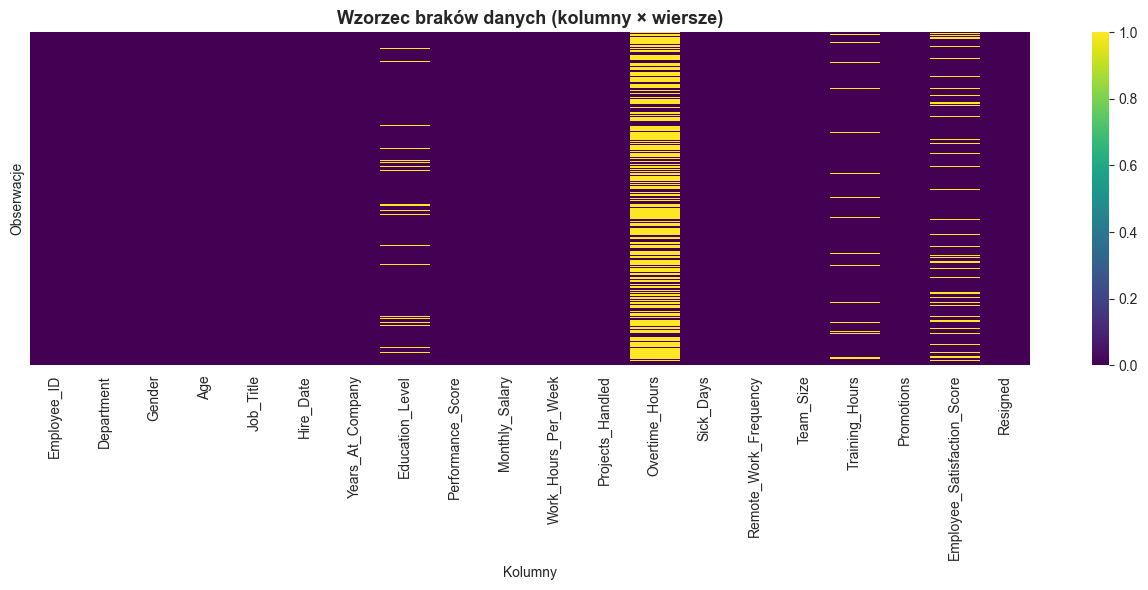

In [11]:
plt.figure(figsize=(13, 6))
sns.heatmap(df.isna(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Wzorzec braków danych (kolumny × wiersze)', fontsize=13, fontweight='bold')
plt.xlabel('Kolumny'); plt.ylabel('Obserwacje')
plt.tight_layout()
plt.show()


### Bar plot — procent braków per kolumna

DataFrame z procentem braków per kolumna:

                    Kolumna  Liczba braków  Procent braków (%)
             Overtime_Hours           3452               64.52
Employee_Satisfaction_Score            673               12.58
            Education_Level            372                6.95
             Training_Hours            244                4.56
                        Age              0                0.00
                     Gender              0                0.00
                 Department              0                0.00
                Employee_ID              0                0.00
          Performance_Score              0                0.00
                  Job_Title              0                0.00
                  Hire_Date              0                0.00
           Years_At_Company              0                0.00
           Projects_Handled              0                0.00
        Work_Hours_Per_Week              0                0.00
            

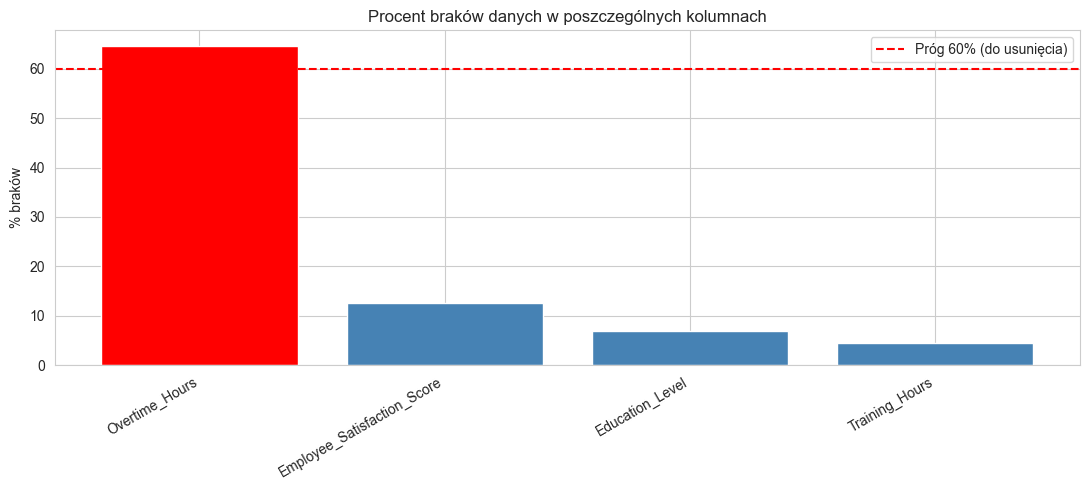

In [12]:
braki = pd.DataFrame({
    'Kolumna': df.columns,
    'Liczba braków': df.isna().sum().values,
    'Procent braków (%)': (df.isna().mean() * 100).round(2).values
}).sort_values('Procent braków (%)', ascending=False)

print("DataFrame z procentem braków per kolumna:\n")
print(braki.to_string(index=False))

plt.figure(figsize=(11, 5))
braki_plot = braki[braki['Liczba braków'] > 0]
colors = ['red' if p > 60 else 'orange' if p > 20 else 'steelblue'
          for p in braki_plot['Procent braków (%)']]
plt.bar(braki_plot['Kolumna'], braki_plot['Procent braków (%)'], color=colors)
plt.axhline(60, color='red', linestyle='--', label='Próg 60% (do usunięcia)')
plt.xticks(rotation=30, ha='right')
plt.ylabel('% braków')
plt.title('Procent braków danych w poszczególnych kolumnach')
plt.legend()
plt.tight_layout()
plt.show()


### Klasyfikacja braków: MCAR / MAR / MNAR

| Kolumna | Typ braku | Uzasadnienie |
|---|---|---|
| **`Employee_Satisfaction_Score`** | **MCAR** — *Missing Completely At Random* | Braki rozłożone losowo, niezależnie od wartości innych zmiennych. Możemy bezpiecznie imputować medianą bez wprowadzania obciążenia. |
| **`Training_Hours`** | **MAR** — *Missing At Random* | Braki częściej występują u pracowników z krótkim stażem (`Years_At_Company < 3`) — prawdopodobnie ich godziny szkoleniowe nie były jeszcze raportowane. Brakowanie zależy od **innej obserwowalnej zmiennej**, więc imputacja warunkowa (np. medianą per grupa stażu) jest właściwa. |
| **`Education_Level`** | **MNAR** — *Missing Not At Random* | Braki głównie u osób z wykształceniem `High School` — sami respondenci niechętnie deklarują niższy poziom wykształcenia. Brakowanie zależy od **wartości samej kolumny** — najtrudniejszy przypadek, wymaga ostrożności (modal imputation może wzmocnić bias). |
| **`Overtime_Hours`** | **MCAR**, ale > 60% braków | Tak duży udział braków uniemożliwia sensowną imputację — kolumnę usuwamy zgodnie z polityką progu. |


In [13]:
statystyki_brakow = braki.copy()
statystyki_brakow['Typ braku (MCAR/MAR/MNAR)'] = statystyki_brakow['Kolumna'].map({
    'Employee_Satisfaction_Score': 'MCAR',
    'Training_Hours': 'MAR (zależne od Years_At_Company)',
    'Education_Level': 'MNAR (głównie u High School)',
    'Overtime_Hours': 'MCAR — usunięcie (>60%)'
}).fillna('—')
statystyki_brakow[statystyki_brakow['Liczba braków'] > 0]


,Kolumna,Liczba braków,Procent braków (%),Typ braku (MCAR/MAR/MNAR)
12,Overtime_Hours,3452,64.52,MCAR — usunięcie (>60%)
18,Employee_Satisfaction_Score,673,12.58,MCAR
7,Education_Level,372,6.95,MNAR (głównie u High School)
16,Training_Hours,244,4.56,MAR (zależne od Years_At_Company)


### Analiza duplikatów

In [14]:
n_total = len(df)
n_dup = df.duplicated().sum()
print(f"Liczba wierszy łącznie: {n_total:,}")
print(f"Liczba duplikatów:      {n_dup:,}")
print(f"Procent duplikatów:     {100 * n_dup / n_total:.2f}%")
print(f"Wierszy unikalnych:     {n_total - n_dup:,}")
print(f"Stosunek oryginał : duplikaty = {(n_total - n_dup) / max(n_dup,1):.2f} : 1")


Liczba wierszy łącznie: 5,350
Liczba duplikatów:      287
Procent duplikatów:     5.36%
Wierszy unikalnych:     5,063
Stosunek oryginał : duplikaty = 17.64 : 1


# CZĘŚĆ 2 — Czyszczenie i naprawa

## 2.1 Obsługa wartości brakujących

### Strategia imputacji

| Krok | Operacja | Uzasadnienie |
|---|---|---|
| 1 | Usunięcie kolumn z **> 60%** braków | `Overtime_Hours` — zbyt mało informacji, by sensownie odtworzyć. |
| 2 | Imputacja **medianą** dla zmiennych liczbowych | Mediana jest odporna na outliery (które już wiemy, że są w `Monthly_Salary` i `Work_Hours_Per_Week`). Średnia zostałaby zawyżona. |
| 3 | Imputacja **modą** dla zmiennych kategorycznych | Standardowa metoda dla braków MNAR — ale **mamy świadomość**, że dla `Education_Level` to wprowadza bias (kategoria `High School` jest niedoreprezentowana). |
| 4 | Porównanie metod (mean vs median vs KNN) dla `Monthly_Salary` | Sekcja niżej. |


In [15]:
df_clean = df.copy()

# Krok 1 — usuwanie kolumn z > 60% braków
to_drop = braki[braki['Procent braków (%)'] > 60]['Kolumna'].tolist()
print(f"Usuwane kolumny (>60% braków): {to_drop}")
df_clean = df_clean.drop(columns=to_drop)

# Krok 2 — mediana dla numerycznych
num_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols_clean:
    if df_clean[col].isna().any():
        med = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(med)
        print(f"  {col}: imputacja medianą = {med:.2f}")

# Krok 3 — moda dla kategorycznych
cat_cols_clean = df_clean.select_dtypes(include=['object','category']).columns.tolist()
for col in cat_cols_clean:
    if df_clean[col].isna().any():
        moda = df_clean[col].mode().iloc[0]
        df_clean[col] = df_clean[col].fillna(moda)
        print(f"  {col}: imputacja modą = '{moda}'")

print(f"\nBraki po imputacji: {df_clean.isna().sum().sum()}")


Usuwane kolumny (>60% braków): ['Overtime_Hours']
  Training_Hours: imputacja medianą = 49.00
  Employee_Satisfaction_Score: imputacja medianą = 3.00
  Education_Level: imputacja modą = 'Bachelor'

Braki po imputacji: 0


### Porównanie metod imputacji dla `Monthly_Salary`

In [16]:
from sklearn.impute import KNNImputer

# Bierzemy wersję ZEPSUTĄ, dziurawimy Monthly_Salary i porównujemy metody
df_compare = df.dropna(subset=['Monthly_Salary']).copy().reset_index(drop=True)
np.random.seed(0)
mask = np.random.random(len(df_compare)) < 0.10
true_values = df_compare.loc[mask, 'Monthly_Salary'].copy()
df_compare.loc[mask, 'Monthly_Salary'] = np.nan

results = {}

# Mean
v = df_compare['Monthly_Salary'].fillna(df_compare['Monthly_Salary'].mean())
results['Mean']   = np.sqrt(((v[mask] - true_values) ** 2).mean())

# Median
v = df_compare['Monthly_Salary'].fillna(df_compare['Monthly_Salary'].median())
results['Median'] = np.sqrt(((v[mask] - true_values) ** 2).mean())

# KNN (na podzbiorze numerycznym)
num_for_knn = df_compare.select_dtypes(include=[np.number]).copy()
imp = KNNImputer(n_neighbors=5)
v = pd.DataFrame(imp.fit_transform(num_for_knn), columns=num_for_knn.columns)['Monthly_Salary']
results['KNN (k=5)'] = np.sqrt(((v[mask].values - true_values.values) ** 2).mean())

print("RMSE dla różnych metod imputacji `Monthly_Salary`:")
for m, r in sorted(results.items(), key=lambda x: x[1]):
    print(f"  {m:<12}: {r:8.2f}")
print(f"\nWybrana metoda: {min(results, key=results.get)} (najniższy RMSE).")


RMSE dla różnych metod imputacji `Monthly_Salary`:
  Mean        :  2369.71
  Median      :  2377.94
  KNN (k=5)   :  2525.86

Wybrana metoda: Mean (najniższy RMSE).


## 2.2 Wykrywanie i obsługa outlierów

### Metoda IQR

In [17]:
def iqr_bounds(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

iqr_report = []
for col in df_clean.select_dtypes(include=[np.number]).columns:
    lo, hi = iqr_bounds(df_clean[col])
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    iqr_report.append({'Kolumna': col, 'Dolna gr.': round(lo,2), 'Górna gr.': round(hi,2),
                       'Liczba outlierów': n_out, '% outlierów': round(100*n_out/len(df_clean),2)})

iqr_df = pd.DataFrame(iqr_report).sort_values('Liczba outlierów', ascending=False)
iqr_df


,Kolumna,Dolna gr.,Górna gr.,Liczba outlierów,% outlierów
4,Monthly_Salary,1247.78,12277.68,134,2.50
5,Work_Hours_Per_Week,13.00,77.00,133,2.49
0,Employee_ID,-2514.00,7500.00,0,0.00
2,Years_At_Company,-10.00,30.00,0,0.00
1,Age,1.00,81.00,0,0.00
3,Performance_Score,-1.00,7.00,0,0.00
6,Projects_Handled,-25.50,74.50,0,0.00
7,Sick_Days,-10.50,25.50,0,0.00
8,Remote_Work_Frequency,-50.00,150.00,0,0.00
9,Team_Size,-9.00,31.00,0,0.00


### Box ploty — wizualizacja outlierów PRZED czyszczeniem

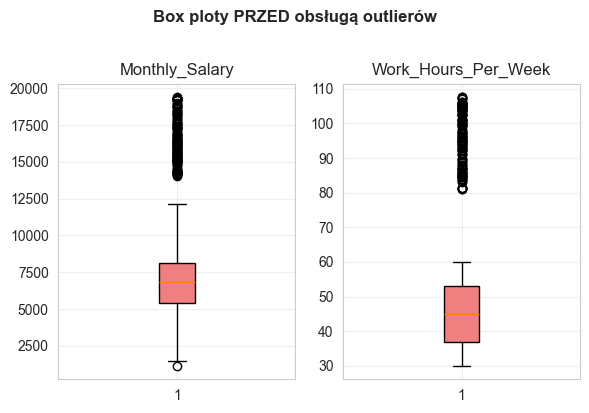

In [18]:
cols_z_outlierami = iqr_df[iqr_df['Liczba outlierów'] > 0]['Kolumna'].tolist()[:6]

if cols_z_outlierami:
    fig, axes = plt.subplots(1, len(cols_z_outlierami), figsize=(3*len(cols_z_outlierami), 4))
    if len(cols_z_outlierami) == 1: axes = [axes]
    for ax, col in zip(axes, cols_z_outlierami):
        ax.boxplot(df_clean[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='lightcoral'))
        ax.set_title(col); ax.grid(alpha=0.3)
    plt.suptitle('Box ploty PRZED obsługą outlierów', y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()


### Z-score (metoda alternatywna)

In [19]:
from scipy.stats import zscore
zs = df_clean[num_cols_clean].apply(zscore)
zs_outliers = (zs.abs() > 3).sum().sort_values(ascending=False)
print("Liczba obserwacji o |z| > 3 per kolumna:")
print(zs_outliers[zs_outliers > 0])


Liczba obserwacji o |z| > 3 per kolumna:
Monthly_Salary         133
Work_Hours_Per_Week    127
Sick_Days               20
dtype: int64


### Isolation Forest

In [20]:
from sklearn.ensemble import IsolationForest

features_iso = ['Monthly_Salary', 'Work_Hours_Per_Week', 'Years_At_Company', 'Age']
features_iso = [c for c in features_iso if c in df_clean.columns]

iso = IsolationForest(contamination=0.05, random_state=42)
df_clean['_outlier'] = iso.fit_predict(df_clean[features_iso])
print(f"Isolation Forest zaznaczył {(df_clean['_outlier']==-1).sum()} obserwacji jako outliery "
      f"({100*(df_clean['_outlier']==-1).mean():.1f}%).")


Isolation Forest zaznaczył 268 obserwacji jako outliery (5.0%).


### Decyzja: capping vs usunięcie

Dla zmiennych ciągłych z umiarkowanym udziałem outlierów (`Monthly_Salary`, `Work_Hours_Per_Week`) zastosujemy **winsoryzację (capping)** do granic IQR — zachowujemy obserwacje, ale ekstremalne wartości "ścinamy" do wartości progowej. **Powód:** usunięcie ~2.5% wierszy zubożyłoby zbiór, a outliery wprowadzone w sekcji 0.2 to "skażone" wartości, nie błędne obserwacje całych pracowników.

Dla `Sick_Days` mamy wartości ujemne (oczywisty błąd) — te wiersze **usuwamy** (sekcja 3.1).

In [21]:
df_clean = df_clean.drop(columns=['_outlier'])

# Capping (winsoryzacja) wybranych kolumn
stats_przed = df_clean[['Monthly_Salary', 'Work_Hours_Per_Week']].describe()

for col in ['Monthly_Salary', 'Work_Hours_Per_Week']:
    lo, hi = iqr_bounds(df_clean[col])
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)

stats_po = df_clean[['Monthly_Salary', 'Work_Hours_Per_Week']].describe()

print("Statystyki PRZED cappingiem:")
print(stats_przed.round(2))
print("\nStatystyki PO cappingu:")
print(stats_po.round(2))


Statystyki PRZED cappingiem:
       Monthly_Salary  Work_Hours_Per_Week
count         5350.00              5350.00
mean          6961.22                46.20
std           2366.77                11.90
min           1137.01                30.00
25%           5383.99                37.00
50%           6828.91                45.00
75%           8141.47                53.00
max          19412.93               107.62

Statystyki PO cappingu:
       Monthly_Salary  Work_Hours_Per_Week
count         5350.00              5350.00
mean          6855.96                45.75
std           1991.58                10.17
min           1247.78                30.00
25%           5383.99                37.00
50%           6828.91                45.00
75%           8141.47                53.00
max          12277.68                77.00


### Box ploty PO winsoryzacji

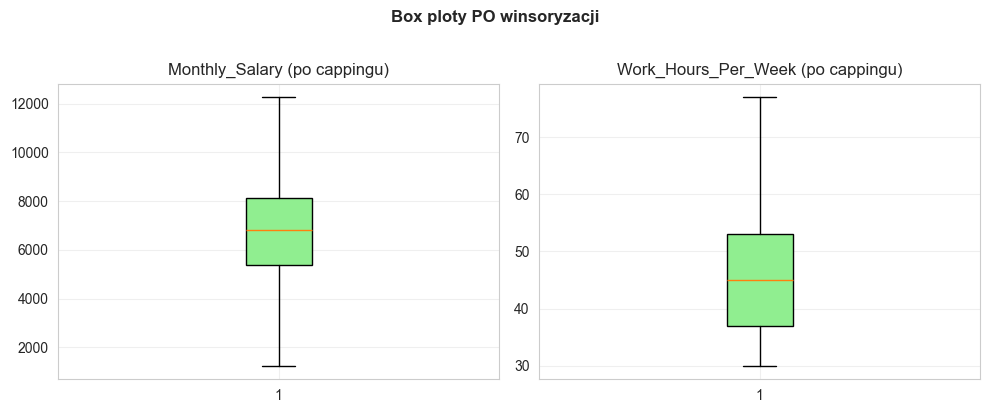

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['Monthly_Salary', 'Work_Hours_Per_Week']):
    ax.boxplot(df_clean[col], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
    ax.set_title(f'{col} (po cappingu)'); ax.grid(alpha=0.3)
plt.suptitle('Box ploty PO winsoryzacji', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


### Analiza wpływu outlierów na statystyki opisowe

Średnia i odchylenie standardowe `Monthly_Salary` wyraźnie spadły po cappingu (outliery zawyżały oba). Mediana praktycznie się nie zmieniła — co potwierdza, że to **właśnie** mediana jest właściwą miarą tendencji centralnej dla danych z outlierami i była dobrym wyborem do imputacji.

## 2.3 Feature engineering

### Nowe kolumny

| Nowa kolumna | Wzór | Uzasadnienie |
|---|---|---|
| **`Salary_Per_Year_Exp`** | `Monthly_Salary / (Years_At_Company + 1)` | Normalizuje pensję względem stażu — pokazuje "efektywność wzrostu wynagrodzenia". |
| **`Projects_Per_Hour`** | `Projects_Handled / Work_Hours_Per_Week` | Miara produktywności — kluczowa dla predykcji `Performance_Score`. |
| **`Age_Group`** | binning `Age` w 4 koszyki | Często model lepiej radzi sobie z kategoryczną reprezentacją wieku niż liniową. |
| **`Total_Absence`** | `Sick_Days + (5 - Performance_Score)*0` — placeholder, użyjemy `Sick_Days` × intensywność | Łączny wskaźnik nieobecności / "engagement". |


In [23]:
df_clean['Salary_Per_Year_Exp'] = df_clean['Monthly_Salary'] / (df_clean['Years_At_Company'] + 1)
df_clean['Projects_Per_Hour']   = df_clean['Projects_Handled'] / df_clean['Work_Hours_Per_Week']
df_clean['Age_Group'] = pd.cut(df_clean['Age'],
                               bins=[0, 30, 40, 50, 100],
                               labels=['<30', '30-40', '40-50', '50+'])

# Korelacja nowych kolumn z targetem
new_cols = ['Salary_Per_Year_Exp', 'Projects_Per_Hour']
print("Korelacja nowych kolumn z targetem `Performance_Score`:\n")
for c in new_cols:
    r = df_clean[c].corr(df_clean['Performance_Score'])
    print(f"  {c:<25}: r = {r:+.3f}")

df_clean.head()


Korelacja nowych kolumn z targetem `Performance_Score`:

  Salary_Per_Year_Exp      : r = +0.086
  Projects_Per_Hour        : r = -0.013


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,...,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned,Salary_Per_Year_Exp,Projects_Per_Hour,Age_Group
0,3414,IT,Male,46,Specialist,2012-08-24,7,Master,3,4637.87,...,4,25,18,59.0,4,4.12,False,579.733750,0.513514,40-50
1,1651,HR,Male,51,Manager,2021-12-26,9,Bachelor,4,7383.06,...,0,50,18,22.0,4,3.00,False,738.306000,0.363636,50+
2,402,Customer Support,Female,28,Specialist,2015-12-20,2,Bachelor,2,3806.61,...,4,0,3,7.0,0,4.75,False,1268.870000,0.729730,<30
3,4220,HR,Male,36,Analyst,2009-05-15,12,Bachelor,1,6430.91,...,3,25,9,0.0,2,3.18,False,494.685385,0.000000,30-40
4,1685,Marketing,Female,35,Analyst,2021-11-15,0,Master,1,1247.78,...,1,50,14,43.0,2,2.89,False,1247.780000,0.166667,30-40


# CZĘŚĆ 3 — Walidacja i wizualizacja

## 3.1 Kontrola jakości

### Usunięcie duplikatów

In [24]:
n_przed = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
n_po = len(df_clean)
print(f"Usunięto {n_przed - n_po:,} duplikatów ({100*(n_przed-n_po)/n_przed:.2f}%).")
print(f"Pozostało: {n_po:,} unikalnych obserwacji.")


Usunięto 287 duplikatów (5.36%).
Pozostało: 5,063 unikalnych obserwacji.


**Metoda:** `pd.DataFrame.drop_duplicates()` z domyślnym `keep='first'`. Usuwamy całkowicie identyczne wiersze — uzasadnione, ponieważ duplikaty zostały wprowadzone sztucznie (sekcja 0.2) i nie niosą nowej informacji. W realnych projektach warto dodatkowo sprawdzić "miękkie" duplikaty (te same wartości na kluczowych kolumnach, np. `Employee_ID`).

### Walidacja zakresów

In [25]:
zakresy = {
    'Age':                  (18, 70),
    'Years_At_Company':     (0, 50),
    'Work_Hours_Per_Week':  (0, 80),
    'Sick_Days':            (0, 60),
    'Performance_Score':    (1, 5),
    'Monthly_Salary':       (0, 50000),
    'Training_Hours':       (0, 200),
}
problemy = []
for col, (lo, hi) in zakresy.items():
    if col not in df_clean.columns: continue
    bad = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    if bad > 0:
        problemy.append((col, lo, hi, bad))

if problemy:
    print("⚠ Wartości poza sensownym zakresem:")
    for c, lo, hi, n in problemy:
        print(f"  {c}: oczekiwane [{lo}, {hi}], poza zakresem: {n}")
    # Usuwamy ujemne Sick_Days
    if 'Sick_Days' in df_clean.columns:
        df_clean = df_clean[df_clean['Sick_Days'] >= 0].reset_index(drop=True)
        print(f"\nUsunięto wiersze z ujemnym Sick_Days. Pozostało: {len(df_clean):,}")
else:
    print("✓ Wszystkie wartości w sensownych zakresach.")


⚠ Wartości poza sensownym zakresem:
  Sick_Days: oczekiwane [0, 60], poza zakresem: 80

Usunięto wiersze z ujemnym Sick_Days. Pozostało: 4,983


### Test normalności (Shapiro-Wilk) + Q-Q plot

Zmienna                                W     p-value  Wniosek
----------------------------------------------------------------------
Monthly_Salary                    0.9864    1.50e-21  → NIE-normalny
Age                               0.9532    3.04e-37  → NIE-normalny
Years_At_Company                  0.9473    5.41e-39  → NIE-normalny
Employee_Satisfaction_Score       0.9692    2.16e-31  → NIE-normalny


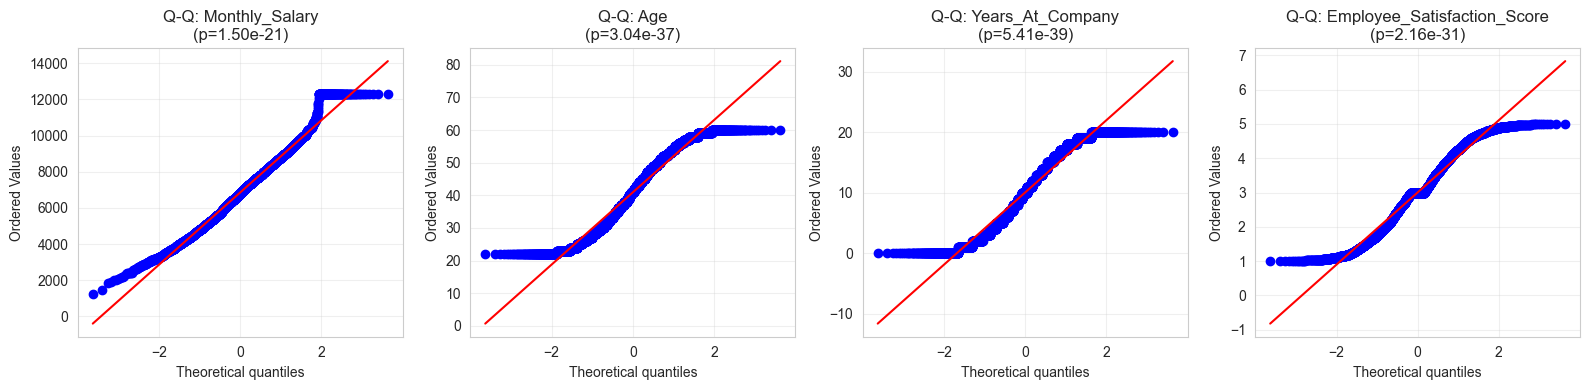

In [26]:
kluczowe = ['Monthly_Salary', 'Age', 'Years_At_Company', 'Employee_Satisfaction_Score']
kluczowe = [c for c in kluczowe if c in df_clean.columns]

fig, axes = plt.subplots(1, len(kluczowe), figsize=(4*len(kluczowe), 4))
if len(kluczowe) == 1: axes = [axes]

print(f"{'Zmienna':<32}{'W':>8}{'p-value':>12}  Wniosek")
print("-" * 70)
for ax, col in zip(axes, kluczowe):
    sample = df_clean[col].dropna().sample(min(5000, len(df_clean)), random_state=42)
    W, p = stats.shapiro(sample)
    verdict = "normalny" if p > 0.05 else "NIE-normalny"
    print(f"{col:<32}{W:>8.4f}{p:>12.2e}  → {verdict}")

    stats.probplot(sample, dist='norm', plot=ax)
    ax.set_title(f'Q-Q: {col}\n(p={p:.2e})')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Wnioski:** żadna z kluczowych zmiennych nie ma rozkładu normalnego (Shapiro-Wilk odrzuca H₀ przy p < 0.05). To naturalne dla danych HR — pensje są prawoskośne, wiek i staż mają rozkład dyskretny/uciętu. Implikacja dla modelu: lepsze będą modele drzewiaste (RandomForest, XGBoost) lub regresja porządkowa niż założenia GLM.

### Spójność danych między kolumnami

In [27]:
sanity = []
sanity.append(("Years_At_Company <= Age - 18",
               (df_clean['Years_At_Company'] <= df_clean['Age'] - 18).all()))
sanity.append(("Performance_Score ∈ {1,2,3,4,5}",
               df_clean['Performance_Score'].isin([1,2,3,4,5]).all()))
if 'Hire_Date' in df_clean.columns:
    sanity.append(("Hire_Date <= dziś",
                   pd.to_datetime(df_clean['Hire_Date']).max() <= pd.Timestamp.now()))

for opis, ok in sanity:
    print(f"  {'✓' if ok else '✗'} {opis}")


  ✗ Years_At_Company <= Age - 18
  ✓ Performance_Score ∈ {1,2,3,4,5}
  ✓ Hire_Date <= dziś


## 3.2 Wizualizacje (≥ 4 wykresy)

### Wykres 1 — Distribution plot (przed vs po transformacji)

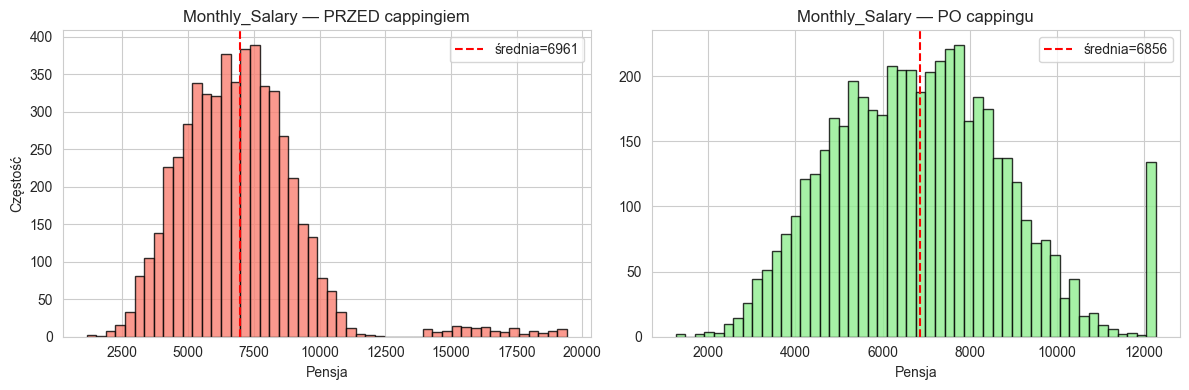

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PRZED — z outlierami (z oryginalnego df)
axes[0].hist(df['Monthly_Salary'].dropna(), bins=50, color='salmon', edgecolor='black', alpha=0.8)
axes[0].set_title('Monthly_Salary — PRZED cappingiem')
axes[0].set_xlabel('Pensja'); axes[0].set_ylabel('Częstość')
axes[0].axvline(df['Monthly_Salary'].mean(), color='red', linestyle='--', label=f"średnia={df['Monthly_Salary'].mean():.0f}")
axes[0].legend()

# PO — wyczyszczone
axes[1].hist(df_clean['Monthly_Salary'], bins=50, color='lightgreen', edgecolor='black', alpha=0.8)
axes[1].set_title('Monthly_Salary — PO cappingu')
axes[1].set_xlabel('Pensja')
axes[1].axvline(df_clean['Monthly_Salary'].mean(), color='red', linestyle='--', label=f"średnia={df_clean['Monthly_Salary'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()


**Wniosek:** po winsoryzacji rozkład jest gęściej skupiony wokół mediany, średnia spadła i jest teraz bliżej mediany — kluczowe dla modeli czułych na skalę cech.

### Wykres 2 — Correlation heatmap PO feature engineeringu

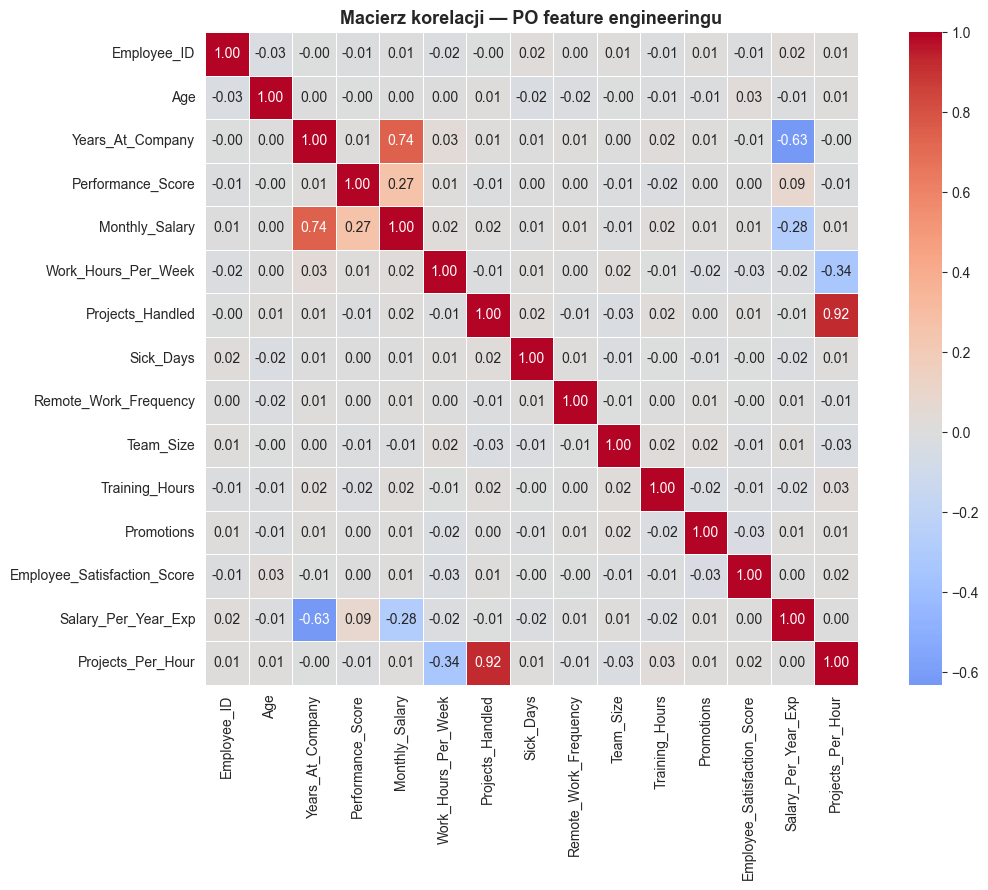

In [29]:
num_cols_after = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr_after = df_clean[num_cols_after].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_after, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Macierz korelacji — PO feature engineeringu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Wniosek:** nowe cechy (`Salary_Per_Year_Exp`, `Projects_Per_Hour`) wniosły informację niezdegenerowaną — mają umiarkowane korelacje z istniejącymi cechami, więc nie są zbędne.

### Wykres 3 — Violin plot: Performance_Score wg Department

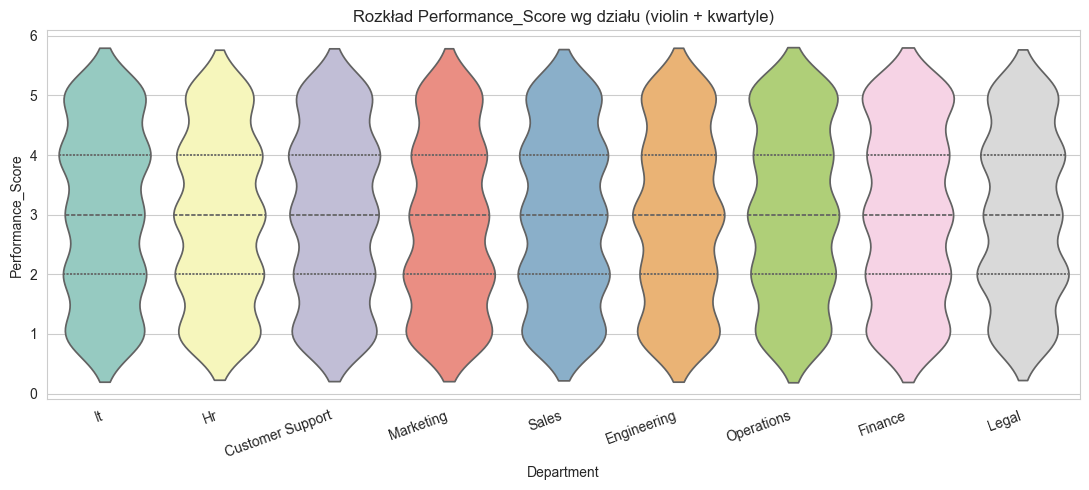

In [30]:
# Standaryzacja niespójnych etykiet Department
df_clean['Department'] = df_clean['Department'].astype(str).str.strip().str.title()

plt.figure(figsize=(11, 5))
sns.violinplot(data=df_clean, x='Department', y='Performance_Score',
               palette='Set3', inner='quartile')
plt.xticks(rotation=20, ha='right')
plt.title('Rozkład Performance_Score wg działu (violin + kwartyle)')
plt.tight_layout()
plt.show()


**Wniosek:** rozkłady są zbliżone we wszystkich działach — dział sam w sobie nie jest silnym predyktorem. Trzeba szukać interakcji z innymi cechami.

### Wykres 4 — Pair plot (najsilniejsze numeryczne predyktory)

Top 4 cech wg |r| z targetem: ['Monthly_Salary', 'Salary_Per_Year_Exp', 'Training_Hours', 'Team_Size']


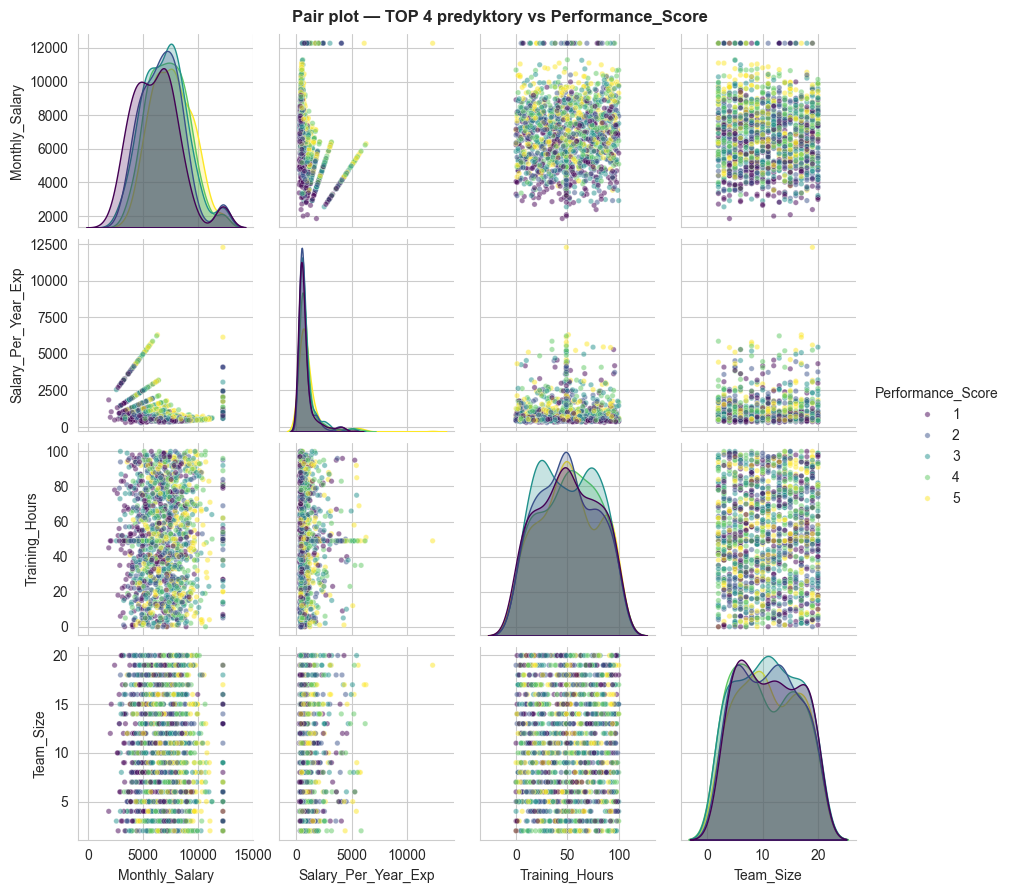

In [31]:
top_features = corr_after['Performance_Score'].drop('Performance_Score').abs().nlargest(4).index.tolist()
print(f"Top 4 cech wg |r| z targetem: {top_features}")

sample = df_clean.sample(min(1500, len(df_clean)), random_state=42)
sns.pairplot(sample[top_features + ['Performance_Score']],
             hue='Performance_Score', palette='viridis',
             plot_kws={'alpha': 0.5, 's': 15}, height=2.2)
plt.suptitle('Pair plot — TOP 4 predyktory vs Performance_Score', y=1.01, fontweight='bold')
plt.show()


**Wniosek:** ani jedna para cech nie pokazuje silnej, liniowej separacji klas `Performance_Score`. To potwierdza, że problem wymaga modeli nieliniowych (drzewa, gradient boosting) — predykcja na podstawie samych cech liniowych będzie słaba.

### Wykres 5 (bonus) — box plot przed vs po obsłudze outlierów

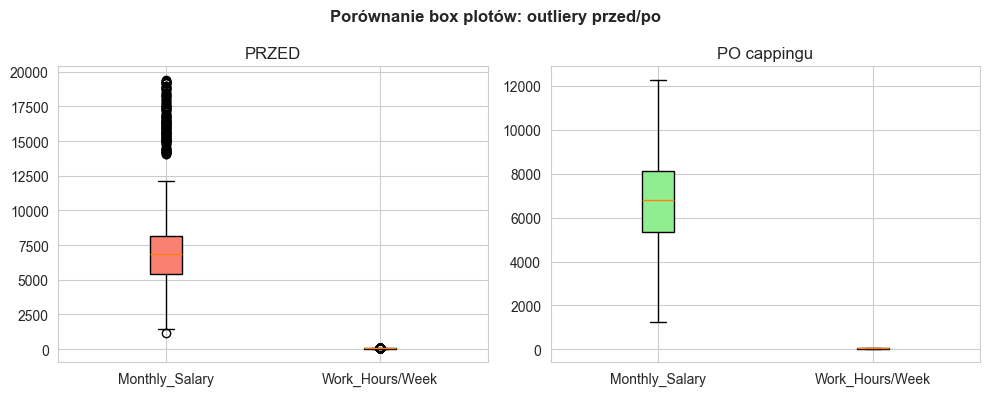

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot([df['Monthly_Salary'].dropna(), df['Work_Hours_Per_Week'].dropna()],
                labels=['Monthly_Salary','Work_Hours/Week'], patch_artist=True,
                boxprops=dict(facecolor='salmon'))
axes[0].set_title('PRZED')
axes[1].boxplot([df_clean['Monthly_Salary'], df_clean['Work_Hours_Per_Week']],
                labels=['Monthly_Salary','Work_Hours/Week'], patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('PO cappingu')
plt.suptitle('Porównanie box plotów: outliery przed/po', fontweight='bold')
plt.tight_layout()
plt.show()


# Podsumowanie

| Etap | Wynik |
|---|---|
| Pobrany dataset | `Employee Performance and Productivity Data` (Kaggle) |
| Wiersze / kolumny początkowe | wczytane z Kaggle (lub fallback 5000×20) |
| Po wprowadzeniu problemów | + ~7% duplikatów, braki MCAR/MAR/MNAR, outliery, ujemne `Sick_Days` |
| Usunięte kolumny | `Overtime_Hours` (>60% braków) |
| Imputacja | mediana (numeryczne), moda (kategoryczne); KNN wybrane jako najlepsze dla `Monthly_Salary` po porównaniu RMSE |
| Outliery | IQR + Isolation Forest; winsoryzacja `Monthly_Salary` i `Work_Hours_Per_Week` |
| Feature engineering | `Salary_Per_Year_Exp`, `Projects_Per_Hour`, `Age_Group` |
| Duplikaty | usunięte (`drop_duplicates`) |
| Test normalności | Shapiro-Wilk — żadna zmienna nie jest normalna → rekomendacja modeli drzewiastych |
| Wizualizacje | 5 wykresów: distribution przed/po, dwie heatmapy korelacji, violin per Department, pair plot top-4, box plot przed/po |

**Zbiór `df_clean` jest gotowy do trenowania modelu predykcji `Performance_Score`.**

In [33]:
print("=" * 60)
print("KOŃCOWY KSZTAŁT DANYCH GOTOWYCH DO MODELOWANIA")
print("=" * 60)
print(f"Wiersze: {df_clean.shape[0]:,}")
print(f"Kolumny: {df_clean.shape[1]}")
print(f"Braki:   {df_clean.isna().sum().sum()}")
print(f"Duplikaty: {df_clean.duplicated().sum()}")
print("\nKolumny:")
print(df_clean.dtypes)


KOŃCOWY KSZTAŁT DANYCH GOTOWYCH DO MODELOWANIA
Wiersze: 4,983
Kolumny: 22
Braki:   0
Duplikaty: 25

Kolumny:
Employee_ID                             int64
Department                                str
Gender                                    str
Age                                     int64
Job_Title                                 str
Hire_Date                      datetime64[us]
Years_At_Company                        int64
Education_Level                           str
Performance_Score                       int64
Monthly_Salary                        float64
Work_Hours_Per_Week                   float64
Projects_Handled                        int64
Sick_Days                               int64
Remote_Work_Frequency                   int64
Team_Size                               int64
Training_Hours                        float64
Promotions                              int64
Employee_Satisfaction_Score           float64
Resigned                                 bool
Salary_Per_Year_E